# Lab: Evaluating Classification Metrics

In this lab, we will explore various classification metrics used to evaluate the performance of two different machine learning models. 

We will use scikit-learn's built-in Breast Cancer dataset for this purpose.

Let's start by importing the necessary libraries and loading the dataset.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
data = load_breast_cancer()
X, y = data.data, data.target
labels = data.target_names
feature_names = data.feature_names

Now let's split the dataset into training and testing sets. We'll use 80% of the data for training and 20% for testing. We also need to standardize the features because KNN and SVM are sensitive to the scale of the data, and scaling helps to ensure that our models perform optimally.

> ⚠️ **Note:** It's very important to fit the scaler only on the training data and then apply the same transformation to the test data. This prevents data leakage and ensures that our model generalizes well to unseen data.

In [27]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Never use fit_transform on test data

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 455
Testing set size: 114


Now it's time to train our models. We'll start with the K-Nearest Neighbors (KNN) classifier, followed by the Support Vector Machine (SVM) classifier. After training each model, we'll make predictions on the test set.

In [28]:
# Train KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Train Support Vector Machine (SVC)
svc = SVC(kernel='rbf', random_state=42)
svc.fit(X_train_scaled, y_train)

print("Models trained successfully!")

Models trained successfully!


In [29]:
# Make predictions on the test set
y_pred_knn = knn.predict(X_test_scaled)
y_pred_svc = svc.predict(X_test_scaled)

Now it's time to evaluate our models using various classification metrics. We'll compute accuracy, precision, recall and F1-score, and plot the confusion matrix.

In [30]:
# Evaluate KNN model
print("=" * 50)
print("KNN Classifier Results")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=labels))

# Evaluate SVC model
print("=" * 50)
print("Support Vector Machine Results")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svc, target_names=labels))

KNN Classifier Results
Accuracy: 0.9474

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Support Vector Machine Results
Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



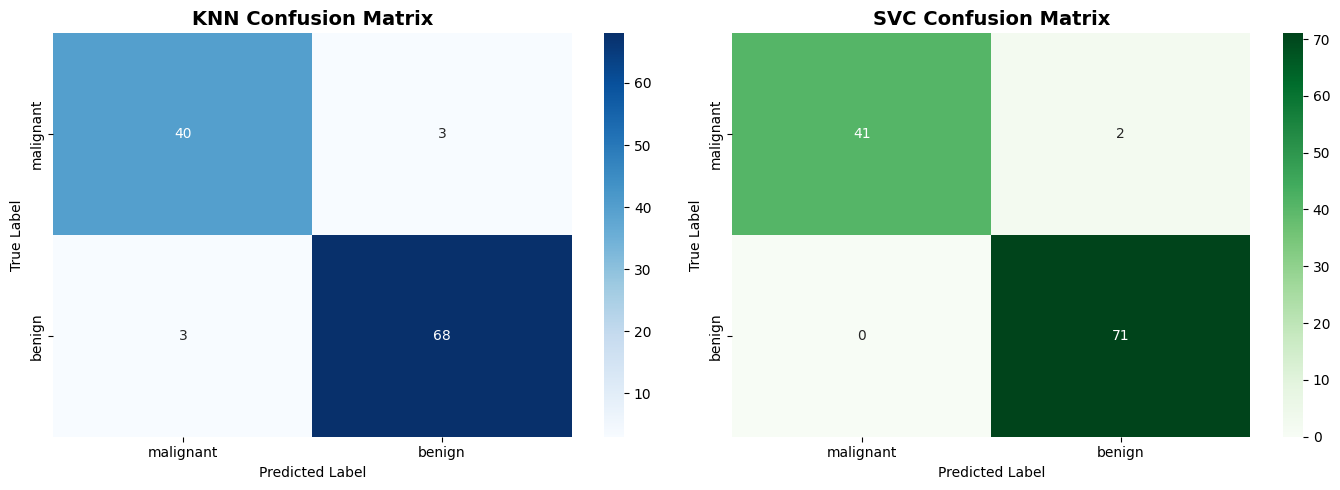

In [31]:
# Compute confusion matrices
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_svc = confusion_matrix(y_test, y_pred_svc)

# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KNN Confusion Matrix
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=labels, yticklabels=labels, cbar=True)
axes[0].set_title('KNN Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# SVC Confusion Matrix
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Greens', ax=axes[1], 
            xticklabels=labels, yticklabels=labels, cbar=True)
axes[1].set_title('SVC Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


---

> ### 📝 Summary of Findings
> 1. **False Negatives are More Critical:** The SVM's perfect recall on benign cases (100%) is particularly valuable in medical diagnosis, as missing a benign case could lead to unnecessary treatment.
> 2. **SVM's Advantage:** The SVM's superior precision on malignant cases (100%) means no false alarms that could cause patient anxiety.
> 3. **Trade-offs:** While KNN is simpler and more interpretable, SVM's 3.5% accuracy improvement is clinically significant in healthcare applications.

---

